# Centrality vs Efficient – Comparative Analysis

This notebook compares evacuation performance across four strategies:
- low awareness + efficient
- low awareness + centrality
- high awareness + efficient
- high awareness + centrality

Goal:
Assess whether centrality-based routing provides systematic advantages over efficient routing,
and whether such advantages depend on the awareness level.

Input:
One or more CSV files exported from `experiment_metrics` from `results\CSV`.

In [274]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Optional (pretty display in notebooks)
from IPython.display import display

In [275]:
def plot_value_counts(series, title, xlabel, ylabel, outname=None, figsize=(5, 4)):
    """
    Plots a bar chart of value counts of a pandas Series.
    """
    counts = series.value_counts()

    plt.figure(figsize=figsize)
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)
    plt.show()

In [276]:
import pandas as pd

def trend_summary_to_strategy_df(
    trend_summary: pd.DataFrame,
    low_col: str,
    high_col: str,
    centrality_label="Centrality",
    efficient_label="Efficient"
) -> pd.DataFrame:
    """
    Converts a yes/no trend summary into a strategy-vs-awareness table.

    Returns:
        DataFrame with index = ["Low Awareness", "High Awareness"]
        columns = ["Centrality", "Efficient"]
    """
    data = {
        centrality_label: [
            trend_summary.loc["yes", low_col],
            trend_summary.loc["yes", high_col],
        ],
        efficient_label: [
            trend_summary.loc["no", low_col],
            trend_summary.loc["no", high_col],
        ],
    }

    return pd.DataFrame(
        data,
        index=["Low Awareness", "High Awareness"]
    )


In [277]:
def plot_centrality_vs_efficient_three_way(
    strategy_df: pd.DataFrame,
    title: str,
    ylabel: str = "Number of Cases",
    outname: str | None = None,
    figsize=(6.5, 4),
    show_values=True
):
    labels = strategy_df.index.tolist()
    x = np.arange(len(labels))

    strategies = ["Centrality", "Efficient", "Equal"]
    n = len(strategies)
    width = 0.75 / n   # total bar width = 0.75

    plt.figure(figsize=figsize)

    bars = []
    for i, s in enumerate(strategies):
        if s not in strategy_df.columns:
            continue

        offsets = x + (i - (n - 1) / 2) * width
        b = plt.bar(offsets, strategy_df[s].values, width, label=s)
        bars.append(b)

        if show_values:
            for bar in b:
                h = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    plt.xticks(x, labels)
    plt.xlabel("Situational Awareness Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)

    plt.show()


## 1) Load one CSV (edit path)


In [278]:
path = "../results/CSV/Cruise_Ship_experiment_metrics.csv"
# path = "../results/CSV/Theme Park_experiment_metrics.csv"
# path = "../results/CSV/corridor_experiment_metrics.csv"

df = pd.read_csv(path)
display(df.head())


,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,case_name.1,risk_nodes,source_nodes,agents_per_source,random_seed
0,1,cruise_ship_case_1,61,Centrality,High,94,0.001099,0.000220,0.002493,15.329787,87.27,91.755,91.545,95.58,96.42,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
1,1,cruise_ship_case_1,61,Centrality,Low,95,0.001088,0.000218,0.006974,15.178947,87.27,91.755,91.545,95.58,96.42,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
2,1,cruise_ship_case_1,61,Efficient,High,94,0.001188,0.000237,0.002593,14.329787,84.15,88.625,88.395,92.46,93.30,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
3,1,cruise_ship_case_1,61,Efficient,Low,112,0.000997,0.000199,0.007425,12.187500,84.15,88.625,88.395,92.46,93.30,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
4,1,cruise_ship_case_1,70,Centrality,High,94,0.000000,0.000000,0.002493,11.351064,72.27,75.810,75.690,78.78,79.74,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233


## 2) Inspect columns (debug cell)

In [279]:
print("Columns in the dataset:")
for col in df.columns:
    print(f"- {col}")

Columns in the dataset:
- experiment_id
- case_name
- agent_group_id
- algorithm
- awareness
- n_records
- mean_remaining_path_risk
- remaining_path_risk_var
- cumulative_risk_exposure
- avg_path_length
- min_time
- avg_time
- median_time
- p90_time
- max_time
- case_name.1
- risk_nodes
- source_nodes
- agents_per_source
- random_seed


## 3) Basic cleanup & normalization
- Remove duplicated join artifact: `case_name.1` if present
- Normalize text fields (lowercase) for stable pivoting
- Ensure numeric KPI columns are numeric

In [280]:
# Drop duplicated case_name column created by joins
if "case_name.1" in df.columns:
    df = df.drop(columns=["case_name.1"])

# Normalize algorithm/awareness to lowercase (safe even if already lowercase)
df["algorithm"] = df["algorithm"].astype(str).str.strip().str.lower()
df["awareness"] = df["awareness"].astype(str).str.strip().str.lower()
df["case_name"] = df["case_name"].astype(str).str.strip()

# Build strategy label (you already have "strategy" column, but we rebuild it deterministically)
df["strategy"] = df["awareness"] + " awareness + " + df["algorithm"]

# Ensure numeric columns are numeric (coerce errors to NaN)
numeric_cols = [
    "n_records",
    "mean_remaining_path_risk",
    "remaining_path_risk_var",
    "cumulative_risk_exposure",
    "avg_path_length",
    "min_time",
    "avg_time",
    "median_time",
    "p90_time",
    "max_time",
    "random_seed",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

display(df.head())

,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,risk_nodes,source_nodes,agents_per_source,random_seed,strategy
0,1,cruise_ship_case_1,61,centrality,high,94,0.001099,0.000220,0.002493,15.329787,87.27,91.755,91.545,95.58,96.42,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233,high awareness + centrality
1,1,cruise_ship_case_1,61,centrality,low,95,0.001088,0.000218,0.006974,15.178947,87.27,91.755,91.545,95.58,96.42,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233,low awareness + centrality
2,1,cruise_ship_case_1,61,efficient,high,94,0.001188,0.000237,0.002593,14.329787,84.15,88.625,88.395,92.46,93.30,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233,high awareness + efficient
3,1,cruise_ship_case_1,61,efficient,low,112,0.000997,0.000199,0.007425,12.187500,84.15,88.625,88.395,92.46,93.30,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233,low awareness + efficient
4,1,cruise_ship_case_1,70,centrality,high,94,0.000000,0.000000,0.002493,11.351064,72.27,75.810,75.690,78.78,79.74,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233,high awareness + centrality


## 4) Sanity checks
Ensure the four expected combinations exist:
- low/efficient, low/centrality, high/efficient, high/centrality

In [281]:
pivot_avg = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],  # ahora son 'low'/'high' y 'centrality'/'efficient'
    values="avg_time",
    aggfunc="mean"
)

display(pivot_avg.head())

# LOW awareness
low_c = pivot_avg[("low", "centrality")]
low_e = pivot_avg[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal = low_c == low_e

# HIGH awareness
high_c = pivot_avg[("high", "centrality")]
high_e = pivot_avg[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal = high_c == high_e


awareness                 high                  low          
algorithm           centrality efficient centrality efficient
case_name                                                    
cruise_ship_case_1     94.9508   92.0932    93.7526   98.7760
cruise_ship_case_10   107.4780  104.9220   127.1940  158.1840
cruise_ship_case_2    102.6644   99.8724   117.5376  118.6588
cruise_ship_case_3    102.8448  100.5210   104.2618  111.2660
cruise_ship_case_4     75.7298   67.6478    77.6846   79.8076

In [282]:
expected = {
    ("low", "efficient"),
    ("low", "centrality"),
    ("high", "efficient"),
    ("high", "centrality"),
}
present = set(zip(df["awareness"], df["algorithm"]))
missing = expected - present

print("Present (awareness, algorithm) pairs:", sorted(present))
if missing:
    print("⚠️ Missing expected pairs:", sorted(missing))
else:
    print("✅ All four expected strategy combinations are present.")

Present (awareness, algorithm) pairs: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]
✅ All four expected strategy combinations are present.


## 5) Global summary (aggregate across all cases)
This answers: "Overall, which strategy tends to be better?"

In [283]:
summary_global = (
    df
    .groupby("strategy", as_index=False)
    .agg(
        n_rows=("case_name", "size"),
        n_cases=("case_name", "nunique"),
        avg_time_mean=("avg_time", "mean"),
        avg_time_median=("avg_time", "median"),
        median_time_mean=("median_time", "mean"),
        p90_time_mean=("p90_time", "mean"),
        max_time_mean=("max_time", "mean"),
        min_time_mean=("min_time", "mean"),
        risk_exposure_mean=("cumulative_risk_exposure", "mean"),
        remaining_risk_mean=("mean_remaining_path_risk", "mean"),
    )
    .sort_values(["avg_time_mean", "p90_time_mean"], ascending=True)
)

display(summary_global)

,strategy,n_rows,n_cases,avg_time_mean,avg_time_median,median_time_mean,p90_time_mean,max_time_mean,min_time_mean,risk_exposure_mean,remaining_risk_mean
1,high awareness + efficient,27,11,94.177333,90.366,94.110000,98.452222,99.314444,88.770000,0.004705,0.001188
0,high awareness + centrality,27,11,97.565667,104.514,97.301111,101.917667,103.202222,92.351111,0.004282,0.001057
2,low awareness + centrality,27,11,102.364037,104.514,102.400556,105.617333,106.488889,98.136667,0.009714,0.009678
3,low awareness + efficient,27,11,108.476593,93.084,108.357222,111.772667,112.585556,104.525556,0.010614,0.018860


## 6) Case-wise comparison (centrality vs efficient within each awareness)
This answers: "In case X, was centrality better than efficient? Does the trend repeat?"

In [284]:
# Add boolean indicators: centrality better than efficient
# (lower time is better)
pivot_avg["low: centrality better"] = pivot_avg[("low", "centrality")] < pivot_avg[("low", "efficient")]
pivot_avg["high: centrality better"] = pivot_avg[("high", "centrality")] < pivot_avg[("high", "efficient")]

# Also compute deltas (efficient - centrality): positive means centrality is better (smaller time)
pivot_avg["low: Δ(efficient - centrality)"] = pivot_avg[("low", "efficient")] - pivot_avg[("low", "centrality")]
pivot_avg["high: Δ(efficient - centrality)"] = pivot_avg[("high", "efficient")] - pivot_avg[("high", "centrality")]

display(pivot_avg)

awareness                 high                  low            \
algorithm           centrality efficient centrality efficient   
case_name                                                       
cruise_ship_case_1     94.9508   92.0932    93.7526   98.7760   
cruise_ship_case_10   107.4780  104.9220   127.1940  158.1840   
cruise_ship_case_2    102.6644   99.8724   117.5376  118.6588   
cruise_ship_case_3    102.8448  100.5210   104.2618  111.2660   
cruise_ship_case_4     75.7298   67.6478    77.6846   79.8076   
cruise_ship_case_5    104.5140   90.3660   104.5140   90.3660   
cruise_ship_case_6    104.5140   90.3660   104.5140   90.3660   
cruise_ship_case_7    107.9400  111.7740   124.4160  134.1960   
cruise_ship_case_8    108.2520  111.8940   111.7440  146.9700   
cruise_ship_case_9    100.0860  100.7100    98.9520  108.1740   
example_case          120.5400  132.0840   126.3120  158.0700   

awareness           low: centrality better high: centrality better  \
algorithm                                                            
case_name                                                            
cruise_ship_case_1                    True                   False   
cruise_ship_case_10                   True                   False   
cruise_ship_case_2                    True                   False   
cruise_ship_case_3                    True                   False   
cruise_ship_case_4                    True                   False   
cruise_ship_case_5                   False                   False   
cruise_ship_case_6                   False                   False   
cruise_ship_case_7                    True                    True   
cruise_ship_case_8                    True                    True   
cruise_ship_case_9                    True                    True   
example_case                          True                    True   

awareness           low: Δ(efficient - centrality)  \
algorithm                                            
case_name                                            
cruise_ship_case_1                          5.0234   
cruise_ship_case_10                        30.9900   
cruise_ship_case_2                          1.1212   
cruise_ship_case_3                          7.0042   
cruise_ship_case_4                          2.1230   
cruise_ship_case_5                        -14.1480   
cruise_ship_case_6                        -14.1480   
cruise_ship_case_7                          9.7800   
cruise_ship_case_8                         35.2260   
cruise_ship_case_9                          9.2220   
example_case                               31.7580   

awareness           high: Δ(efficient - centrality)  
algorithm                                            
case_name                                            
cruise_ship_case_1                          -2.8576  
cruise_ship_case_10                         -2.5560  
cruise_ship_case_2                          -2.7920  
cruise_ship_case_3                          -2.3238  
cruise_ship_case_4                          -8.0820  
cruise_ship_case_5                         -14.1480  
cruise_ship_case_6                         -14.1480  
cruise_ship_case_7                           3.8340  
cruise_ship_case_8                           3.6420  
cruise_ship_case_9                           0.6240  
example_case                                11.5440

## 7) Trend counts (how often centrality wins)
This is a strong "study result" summary.

In [285]:
trend_time_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)

display(trend_time_summary)

,low awareness,high awareness
Centrality better,9,4
Efficient better,2,7
Equal,0,0


,Centrality,Efficient,Equal
Low Awareness,9,2,0
High Awareness,4,7,0


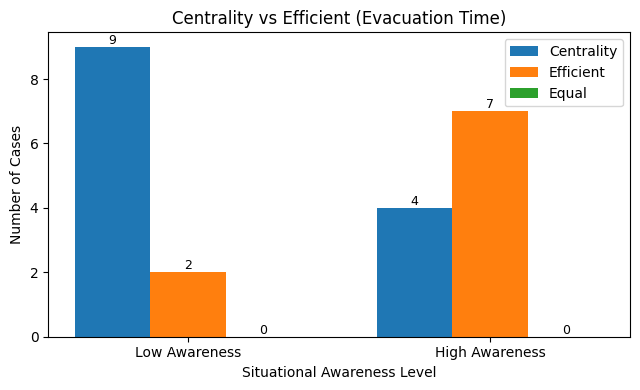

In [286]:
time_df = pd.DataFrame(
    {
        "Centrality": [
            trend_time_summary.loc["Centrality better", "low awareness"],
            trend_time_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_time_summary.loc["Efficient better", "low awareness"],
            trend_time_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_time_summary.loc["Equal", "low awareness"],
            trend_time_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(time_df)

plot_centrality_vs_efficient_three_way(
    time_df,
    title="Centrality vs Efficient (Evacuation Time)",
    outname="centrality_vs_efficient_time_3way"
)



## 8) Case-wise ranking table (which strategy is best per case)
This gives you "best strategy per case" and lets you see if one dominates.


In [287]:
# Create a strategy-wise pivot for avg_time
pivot_strategy = df.pivot_table(
    index="case_name",
    columns="strategy",
    values="avg_time",
    aggfunc="mean"
)

# Rank strategies per case (1 = best/lowest time)
ranked = pivot_strategy.rank(axis=1, method="min", ascending=True)

# Identify best strategy label per case
best_strategy = pivot_strategy.idxmin(axis=1)
best_time = pivot_strategy.min(axis=1)

ranking_table = pivot_strategy.copy()
ranking_table["best_strategy"] = best_strategy
ranking_table["best_avg_time"] = best_time

display(ranking_table.sort_values("best_avg_time").head(20))

strategy,high awareness + centrality,high awareness + efficient,low awareness + centrality,low awareness + efficient,best_strategy,best_avg_time
case_name,,,,,,
cruise_ship_case_4,75.7298,67.6478,77.6846,79.8076,high awareness + efficient,67.6478
cruise_ship_case_5,104.5140,90.3660,104.5140,90.3660,high awareness + efficient,90.3660
cruise_ship_case_6,104.5140,90.3660,104.5140,90.3660,high awareness + efficient,90.3660
cruise_ship_case_1,94.9508,92.0932,93.7526,98.7760,high awareness + efficient,92.0932
cruise_ship_case_9,100.0860,100.7100,98.9520,108.1740,low awareness + centrality,98.9520
cruise_ship_case_2,102.6644,99.8724,117.5376,118.6588,high awareness + efficient,99.8724
cruise_ship_case_3,102.8448,100.5210,104.2618,111.2660,high awareness + efficient,100.5210
cruise_ship_case_10,107.4780,104.9220,127.1940,158.1840,high awareness + efficient,104.9220
cruise_ship_case_7,107.9400,111.7740,124.4160,134.1960,high awareness + centrality,107.9400


## 9) Summary of best-strategy frequency
"How many cases does each strategy win?"


In [288]:
best_strategy_counts = best_strategy.value_counts().rename_axis("strategy").reset_index(name="wins")
display(best_strategy_counts)

,strategy,wins
0,high awareness + efficient,7
1,high awareness + centrality,3
2,low awareness + centrality,1


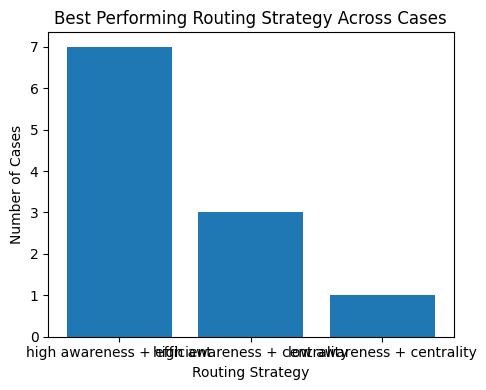

In [289]:
plot_value_counts(
    best_strategy,
    title="Best Performing Routing Strategy Across Cases",
    xlabel="Routing Strategy",
    ylabel="Number of Cases",
    outname="best_strategy_frequency"
)


## 10) Compare by another KPI (risk exposure)
Same structure, but using `cumulative_risk_exposure` (lower is better).


In [290]:
pivot_risk = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],
    values="mean_remaining_path_risk",   # o "cumulative_risk_exposure"
    aggfunc="mean"
)

display(pivot_risk.head())
print("Pivot columns:", pivot_risk.columns.tolist())

low_c = pivot_risk[("low", "centrality")]
low_e = pivot_risk[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal    = low_c == low_e

# HIGH awareness
high_c = pivot_risk[("high", "centrality")]
high_e = pivot_risk[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal    = high_c == high_e


awareness                 high                  low          
algorithm           centrality efficient centrality efficient
case_name                                                    
cruise_ship_case_1    0.000637  0.000587   0.004081  0.007067
cruise_ship_case_10   0.003354  0.010317   0.015520  0.076180
cruise_ship_case_2    0.000693  0.000131   0.019219  0.016634
cruise_ship_case_3    0.001148  0.001168   0.005781  0.011325
cruise_ship_case_4    0.000245  0.000011   0.001940  0.005018

Pivot columns: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]


In [291]:
trend_risk_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)


,low awareness,high awareness
Centrality better,8,5
Efficient better,2,5
Equal,1,1


,Centrality,Efficient,Equal
Low Awareness,8,2,1
High Awareness,5,5,1


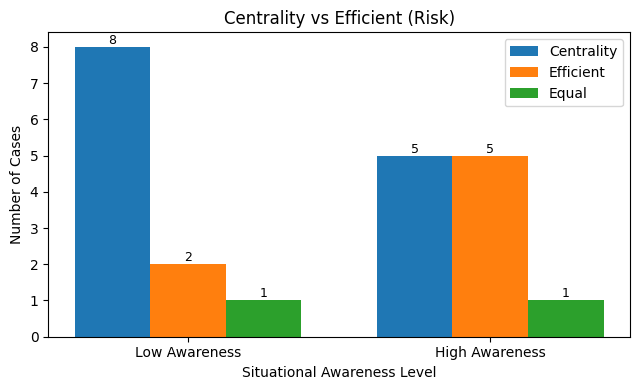

In [292]:
risk_df = pd.DataFrame(
    {
        "Centrality": [
            trend_risk_summary.loc["Centrality better", "low awareness"],
            trend_risk_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_risk_summary.loc["Efficient better", "low awareness"],
            trend_risk_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_risk_summary.loc["Equal", "low awareness"],
            trend_risk_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(risk_df)

plot_centrality_vs_efficient_three_way(
    risk_df,
    title="Centrality vs Efficient (Risk)",
    outname="centrality_vs_efficient_risk_3way"
)
